In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import os

#import from csv and create win cols
pd.set_option('display.max_rows', 200)
X = pd.read_csv('nfl_team_stats_2002-2024.csv')
X = X[X['season'] >=2005].copy()
X['home'] = X['home'].astype(str)
X['away'] = X['away'].astype(str)
X['home_win'] = X['score_home'] > X['score_away']
X['home_win'] = X['home_win'].astype(int)

X['points_allowed_home'] = X['score_away']
X['points_allowed_away'] = X['score_home']
X['yards_allowed_home'] = X['yards_away']
X['yards_allowed_away'] = X['yards_home']
#if you tie at home means the other team "won" as they dont have home field advantage
X


,season,week,date,time_et,neutral,away,home,score_away,score_home,first_downs_away,...,interceptions_home,def_st_td_away,def_st_td_home,possession_away,possession_home,home_win,points_allowed_home,points_allowed_away,yards_allowed_home,yards_allowed_away
801,2005,1,2005-09-08,9:00 PM,False,Raiders,Patriots,20,30,19,...,0,0,0,27:40,32:20,1,20,30,338,379
802,2005,1,2005-09-11,1:00 PM,False,Texans,Bills,7,22,12,...,0,0,0,21:45,38:15,1,7,22,120,316
803,2005,1,2005-09-11,1:00 PM,False,Bengals,Browns,27,13,26,...,2,0,0,34:13,25:47,0,27,13,420,373
804,2005,1,2005-09-11,1:00 PM,False,Jets,Chiefs,7,27,19,...,1,0,0,31:29,28:31,1,7,27,390,389
805,2005,1,2005-09-11,1:00 PM,False,Broncos,Dolphins,10,34,19,...,1,0,2,27:42,32:18,1,10,34,312,426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6209,2024,Division,2025-01-19,3:00 PM,False,Rams,Eagles,22,28,18,...,0,0,0,29:06,30:54,1,22,28,402,350
6210,2024,Division,2025-01-19,6:30 PM,False,Ravens,Bills,25,27,23,...,0,0,0,28:16,31:44,1,25,27,416,273
6211,2024,Conference,2025-01-26,3:00 PM,False,Commanders,Eagles,23,55,22,...,0,0,0,29:29,30:31,1,23,55,350,459
6212,2024,Conference,2025-01-26,6:30 PM,False,Bills,Chiefs,29,32,22,...,0,0,0,30:32,29:28,1,29,32,374,368


In [30]:
def poss_to_seconds(val):
    try:
        m, s = map(int, val.split(':'))
        return m * 60 + s
    except:
        return np.nan
    
#change pos to singular number 
X.loc[:, 'possession_home'] = X['possession_home'].apply(poss_to_seconds)
X.loc[:, 'possession_away'] = X['possession_away'].apply(poss_to_seconds)
X.loc[:,'week'] = pd.to_numeric(X['week'], errors='coerce')
X = X.dropna(subset=['week'])
X= X.copy()


X.loc[:,'game_id'] = X.index




In [31]:
#Find Home Cols and Away cols and split up dataframe based on them to simplify cols and be able to track each team whether they are home or away
home_cols = [col for col in X.columns if col.endswith('_home')]
away_cols = [col for col in X.columns if col.endswith('_away')]

home_df = X[['season', 'week', 'game_id', 'home', 'home_win'] + home_cols].copy()
away_df = X[['season', 'week', 'game_id', 'away'] + away_cols].copy()

home_df = home_df.rename(columns=lambda x: x.replace('_home', '') if x.endswith('_home') else x)
away_df = away_df.rename(columns=lambda x: x.replace('_away', '') if x.endswith('_away') else x)

home_df = home_df.rename(columns={'home': 'team'})
away_df = away_df.rename(columns={'away': 'team'})


In [32]:
long_X = pd.concat([home_df, away_df], ignore_index=True)
long_X = long_X.sort_values(by =['season', 'team', 'week'])
#print(long_X.head(200))

stat_cols = [col for col in long_X.columns if col not in ['season', 'week', 'team', 'game_id', 'home_win']]
print(stat_cols)

#rolling average, shifted by one so all we know are the stats leading up to that game for the current season averages.
rolling_avg = (
    long_X
    .groupby(['season', 'team'])[stat_cols]
    .transform(lambda x: x.shift(1).expanding().mean())
)
print(rolling_avg)

long_X = long_X.sort_values(by=['season', 'team', 'week'])
rolling_X = pd.concat([long_X[['season', 'week', 'team', 'game_id', 'home_win']], rolling_avg], axis=1)
print(rolling_X.head(30))

#merge the two df back together and label to be able to tell which team was the home team
home_stats = rolling_X.merge(X[['game_id', 'home']], left_on=['game_id', 'team'], right_on=['game_id', 'home'])
away_stats = rolling_X.merge(X[['game_id', 'away']], left_on=['game_id', 'team'], right_on=['game_id', 'away'])

home_stats = home_stats.add_suffix('_home')
away_stats = away_stats.add_suffix('_away')

#final merge of home and away stats
final_X = pd.merge(home_stats, away_stats, left_on='game_id_home', right_on='game_id_away')
final_X = final_X.rename(columns={'game_id_home': 'game_id'}).drop(columns=['game_id_away'])

#drop cols that are week 1 as we do not have any existing information about their season yet.
final_X = final_X[final_X['week_home'] > 1].copy()



['score', 'first_downs', 'first_downs_from_passing', 'first_downs_from_rushing', 'first_downs_from_penalty', 'third_down_comp', 'third_down_att', 'fourth_down_comp', 'fourth_down_att', 'plays', 'drives', 'yards', 'pass_comp', 'pass_att', 'pass_yards', 'sacks_num', 'sacks_yards', 'rush_att', 'rush_yards', 'pen_num', 'pen_yards', 'redzone_comp', 'redzone_att', 'fumbles', 'interceptions', 'def_st_td', 'possession', 'points_allowed', 'yards_allowed']
           score  first_downs  first_downs_from_passing  \
10           NaN          NaN                       NaN   
5201   28.000000    12.000000                 10.000000   
41     15.500000    10.000000                  8.500000   
5241   20.666667    13.000000                  9.333333   
68     19.000000    11.750000                  8.750000   
...          ...          ...                       ...   
5108   24.750000    20.583333                 11.833333   
5133   26.076923    20.769231                 12.076923   
10328  26.357143  

In [33]:
#tweak the names for more readability and drop repeat cols that we do not need.
final_X['week'] = final_X['week_home']
final_X['week'] = final_X['week_home']
final_X['season'] = final_X['season_home']
final_X['home_win'] = final_X['home_win_home']
final_X = final_X.drop(['season_home', 'week_home', 'home_home', 'season_away', 'week_away', 'away_away', 'home_win_home', 'home_win_away'], axis =1)

print(final_X.columns)
final_X.head(30)

Index(['team_home', 'game_id', 'score_home', 'first_downs_home',
       'first_downs_from_passing_home', 'first_downs_from_rushing_home',
       'first_downs_from_penalty_home', 'third_down_comp_home',
       'third_down_att_home', 'fourth_down_comp_home', 'fourth_down_att_home',
       'plays_home', 'drives_home', 'yards_home', 'pass_comp_home',
       'pass_att_home', 'pass_yards_home', 'sacks_num_home',
       'sacks_yards_home', 'rush_att_home', 'rush_yards_home', 'pen_num_home',
       'pen_yards_home', 'redzone_comp_home', 'redzone_att_home',
       'fumbles_home', 'interceptions_home', 'def_st_td_home',
       'possession_home', 'points_allowed_home', 'yards_allowed_home',
       'team_away', 'score_away', 'first_downs_away',
       'first_downs_from_passing_away', 'first_downs_from_rushing_away',
       'first_downs_from_penalty_away', 'third_down_comp_away',
       'third_down_att_away', 'fourth_down_comp_away', 'fourth_down_att_away',
       'plays_away', 'drives_away', 'yard

,team_home,game_id,score_home,first_downs_home,first_downs_from_passing_home,first_downs_from_rushing_home,first_downs_from_penalty_home,third_down_comp_home,third_down_att_home,fourth_down_comp_home,...,redzone_att_away,fumbles_away,interceptions_away,def_st_td_away,possession_away,points_allowed_away,yards_allowed_away,week,season,home_win
1,49ers,842,15.500000,10.000000,8.500000,1.000000,0.500000,2.000000,9.500000,0.000000,...,3.000000,0.500000,0.000000,0.000000,1898.000000,19.000000,318.500000,3.0,2005,0.0
2,49ers,869,19.000000,11.750000,8.750000,2.500000,0.500000,3.500000,10.750000,0.000000,...,2.500000,0.000000,0.500000,0.500000,1698.750000,6.500000,320.000000,5.0,2005,0.0
3,49ers,913,16.000000,11.333333,7.000000,3.166667,1.166667,3.333333,11.500000,0.166667,...,2.500000,0.333333,1.166667,0.333333,2041.833333,12.000000,233.333333,8.0,2005,1.0
4,49ers,925,15.857143,11.000000,6.142857,3.714286,1.142857,3.142857,12.142857,0.142857,...,4.428571,0.857143,0.714286,0.285714,1702.142857,19.571429,370.857143,9.0,2005,0.0
5,49ers,955,14.000000,10.555556,5.111111,3.888889,1.555556,3.000000,12.777778,0.222222,...,4.111111,0.555556,0.777778,0.000000,1784.111111,18.000000,313.555556,11.0,2005,0.0
6,49ers,988,15.727273,11.545455,6.181818,3.909091,1.454545,3.181818,13.000000,0.454545,...,2.909091,0.909091,1.272727,0.363636,1836.272727,26.545455,328.909091,13.0,2005,0.0
7,49ers,1052,14.600000,11.466667,5.933333,4.066667,1.466667,2.800000,12.333333,0.333333,...,2.266667,0.733333,0.733333,0.133333,1727.333333,27.400000,366.666667,17.0,2005,1.0
8,Bears,823,7.000000,11.000000,9.000000,2.000000,0.000000,6.000000,13.000000,0.000000,...,3.000000,0.000000,0.000000,0.000000,1736.000000,3.000000,216.000000,2.0,2005,1.0
9,Bears,840,22.500000,14.500000,7.000000,7.500000,0.000000,7.000000,14.000000,0.000000,...,6.000000,0.500000,1.000000,0.000000,2186.500000,10.500000,338.500000,3.0,2005,0.0
10,Bears,882,15.500000,15.250000,7.500000,7.000000,0.750000,5.500000,14.000000,0.500000,...,2.750000,1.250000,2.500000,0.500000,1745.500000,26.750000,378.250000,6.0,2005,1.0


In [34]:
#Prep for model prediction
y = final_X['home_win']
X = final_X.drop(columns=['home_win', 'game_id', 'team_home', 'team_away', 'week'])


train = final_X[final_X['season'] < 2024]
test = final_X[final_X['season'] == 2024]

X_train = train.drop(columns=['home_win', 'game_id', 'team_home', 'team_away', 'week'])
y_train = train['home_win']
X_test = test.drop(columns=['home_win', 'game_id', 'team_home', 'team_away', 'week'])
y_test = test['home_win']


In [42]:
#very first basic model, not looking for anything spectacular, just that we are better than always picking home team (which is 57% historical win rate)
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=600,
    max_depth=2,
    learning_rate=0.02,
    subsample=1,
    colsample_bytree=.5
)

model.fit(X_train, y_train)

# Evaluate
y_pred_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_pred_proba > 0.4).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

Accuracy: 0.59375
ROC AUC: 0.5770736481526793


First model seems to be better than just straight up picking the home team every single time (57% accuracy historically). This is an alright start but I am sure that we can squeeze a whole lot more out of the model with feature tweaking and other tools that we have.

                 feature  importance
29            score_away    0.025847
0             score_home    0.024436
27   points_allowed_home    0.021873
40            yards_away    0.021310
11            yards_home    0.020436
56   points_allowed_away    0.019093
22      redzone_att_home    0.019092
45      sacks_yards_away    0.018305
23          fumbles_home    0.017917
50     redzone_comp_away    0.017857
5   third_down_comp_home    0.017707
16      sacks_yards_home    0.017631
1       first_downs_home    0.017586
43       pass_yards_away    0.017411
24    interceptions_home    0.017320
58                season    0.017288
53    interceptions_away    0.017214
21     redzone_comp_home    0.017075
12        pass_comp_home    0.017030
39           drives_away    0.016950


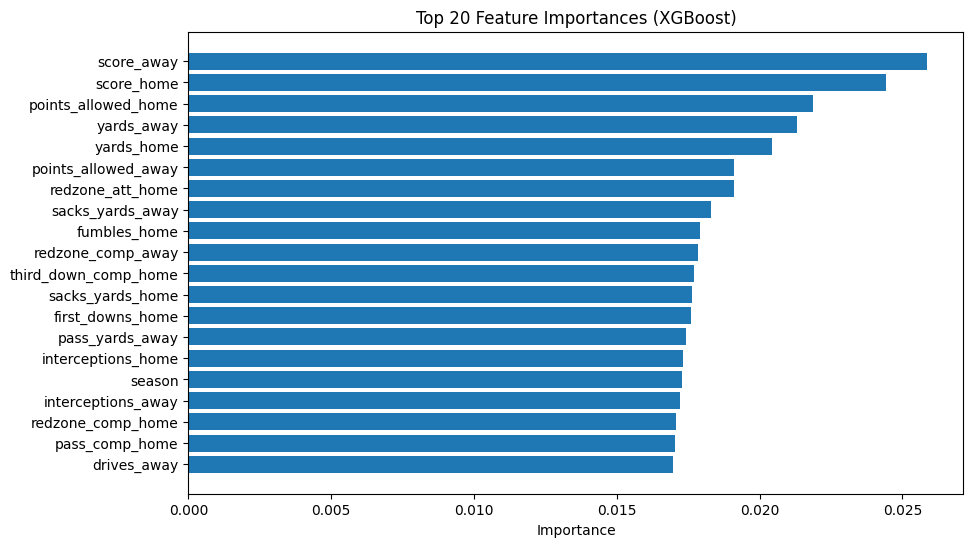

In [8]:
feature_names = X_train.columns
#Lets model what most important features are

importances = model.feature_importances_

feat_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_importances.head(20))  # top 20 features

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_importances['feature'][:20], feat_importances['importance'][:20])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.show()

Seems as though the rolling avg points scored by both home and away teams have the highest importance which is surely to be expected. At the end of the day whoever has scored the most points should win. Probably going to want to start cutting down the number of features that we are including as they are confounding.

In [9]:
#select home and away cols
home_cols = [c for c in final_X.columns if c.endswith("_home")]
away_cols = [c for c in final_X.columns if c.endswith("_away")]
home_cols.remove('team_home')
away_cols.remove('team_away')

home_cols = sorted(home_cols)
away_cols = sorted(away_cols)

#we are going to look at the difference in the two teams per feature in use for upcoming models
for h, a in zip(home_cols, away_cols):
    base = h.replace("_home", "")
    diff_col = f"{base}_diff"
    final_X[diff_col] = X[h] - X[a]

#keep only the cols that are the difference cols and identifiers like week, season and ofc our y in home_win 
diff_cols = [c for c in final_X.columns if c.endswith("_diff")]
X2 = final_X[diff_cols + ['week', 'season', 'home_win']]


train = X2[X2['season'] < 2023]
test = X2[X2['season'] > 2023]

X_train = train.drop(columns=['home_win', 'week'])
y_train = train['home_win']
X_test = test.drop(columns=['home_win', 'week'])
y_test = test['home_win']


In [10]:
#Second Model is focused on using these diff features rather than them individually
model2 = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

model2.fit(X_train, y_train)

# Evaluate
y_pred_proba = model2.predict_proba(X_test)[:,1]
y_pred = (y_pred_proba > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

Accuracy: 0.6328125
ROC AUC: 0.6294347932468803


We see a noticeable improvement with this model. Up about 3.5% accuracy when compared to the individual team stat features found in model 1. Lets keep going and see how good we can get

                          feature  importance
24                     score_diff    0.062491
16            points_allowed_diff    0.042593
28                     yards_diff    0.038297
23               sacks_yards_diff    0.035656
2   first_downs_from_passing_diff    0.034648
22                 sacks_num_diff    0.034504
27             yards_allowed_diff    0.033733
9              interceptions_diff    0.032931
10                  pass_att_diff    0.032761
25            third_down_att_diff    0.032702
21                rush_yards_diff    0.032167
14                 pen_yards_diff    0.031962
0                  def_st_td_diff    0.031742
26           third_down_comp_diff    0.031737
18               redzone_att_diff    0.031715
17                possession_diff    0.031696
12                pass_yards_diff    0.031606
4   first_downs_from_rushing_diff    0.031484
15                     plays_diff    0.031361
13                   pen_num_diff    0.031299


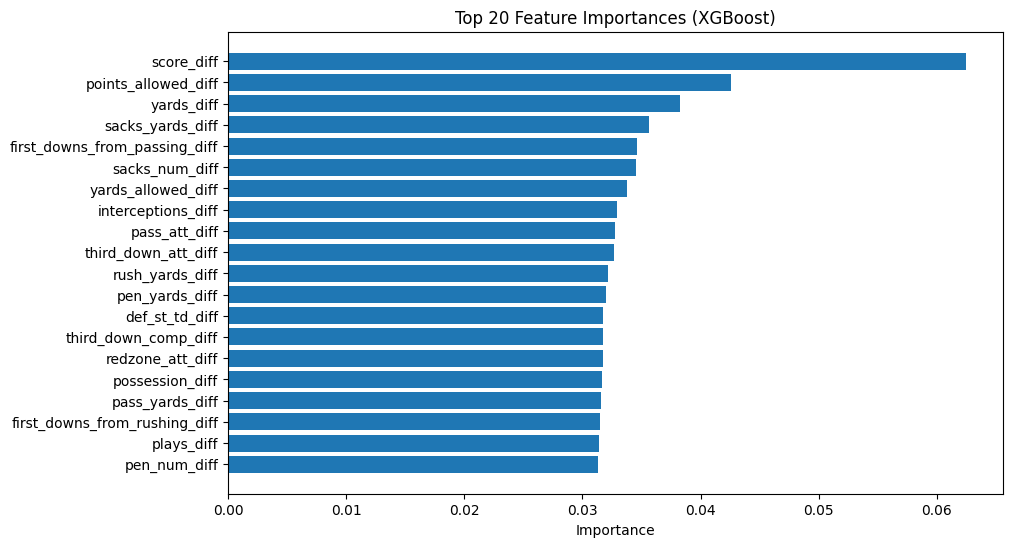

In [11]:
feature_names = X_train.columns


importances = model2.feature_importances_

feat_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_importances.head(20))  # top 20 features

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_importances['feature'][:20], feat_importances['importance'][:20])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.show()

Again here to note that the score_diff feature is still by far and away the most important. Still makes sense and still going to want to eliminate some features that could be confounding.

In [ ]:
model3 = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

week = 1
currCols = ['score_diff',
 'points_allowed_diff',
 'pass_att_diff',
 'pen_yards_diff',
 'first_downs_diff',
 'sacks_yards_diff',
 'first_downs_from_penalty_diff']
model3.fit(X_train[currCols], y_train)

X_test_Week_Lim = test.drop(columns=['home_win'])
X_test_Week_Lim = X_test_Week_Lim[X_test_Week_Lim['week']>week]

y_test_Week_Lim = test[test['week']>week]['home_win']


# Evaluate
y_pred_proba = model3.predict_proba(X_test_Week_Lim[currCols])[:,1]
#print(y_pred_proba)
y_pred = (y_pred_proba > 0.51).astype(int)


print("Accuracy:", accuracy_score(y_test_Week_Lim, y_pred))
print("ROC AUC:", roc_auc_score(y_test_Week_Lim, y_pred))

Accuracy: 0.6953125
ROC AUC: 0.6920724247614387


Here we see that we have gained yet another noticeable improvement in the model. We have an accuracy of about 69.5% now while using far fewer features to get there.

                         feature  importance
0                     score_diff    0.172019
1            points_allowed_diff    0.147703
5               sacks_yards_diff    0.143846
4               first_downs_diff    0.136006
6  first_downs_from_penalty_diff    0.135356
2                  pass_att_diff    0.134389
3                 pen_yards_diff    0.130682


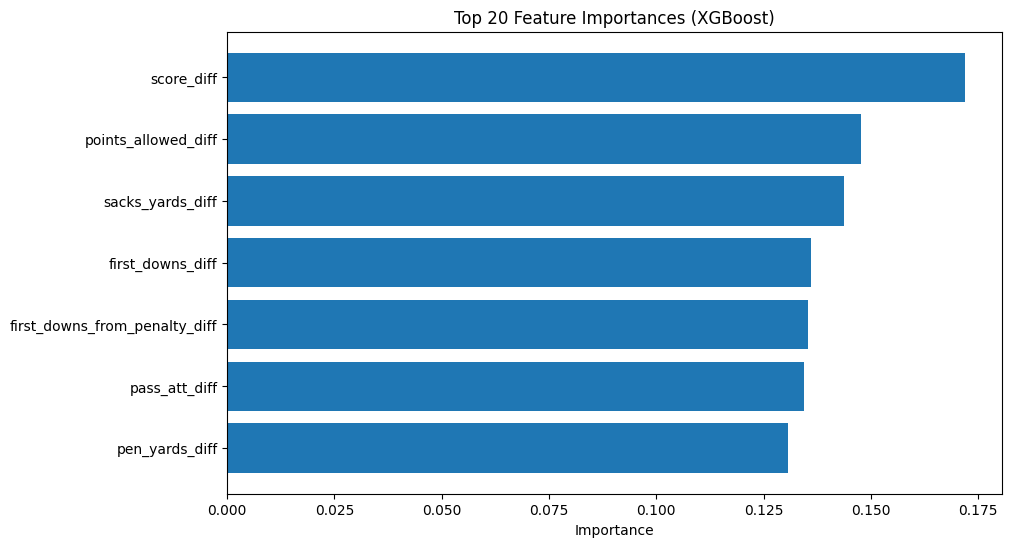

In [13]:
feature_names = currCols


importances = model3.feature_importances_

feat_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_importances.head(20))  # top 20 features

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_importances['feature'][:20], feat_importances['importance'][:20])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.show()

I think that it is pretty clear by now that score is the #1 feature in terms of importance, then probably yards after that. I am going to make an effort to throw yards allowed and points allowed into the df and see if that helps at all.

Back after adding yards and points allowed into the df. It seems as though the points allowed helped a lot, but the yards allowed did not help whatsoever. So I for now am rolling with the following columns ['score_diff', 'yards_diff', 'redzone_att_diff', 'possession_diff', 'sacks_yards_diff', 'first_downs_diff', 'fumbles_diff', 'rush_yards_diff', 'points_allowed_diff']

In [14]:
model4 = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
)

param_grid = {
    'n_estimators': [300, 500, 700],
    'max_depth': [4, 5, 6, 7], 
    'learning_rate': [0.01, 0.05, 0.1], 
    'subsample': [0.6, 0.8, 1.0], 
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}


#Grid search
grid_search = GridSearchCV(
    estimator=model4,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train[currCols], y_train)

#Best params
print("Best parameters:", grid_search.best_params_)
print("Best CV ROC AUC:", grid_search.best_score_)

#Refit on best params
best_model = grid_search.best_estimator_

#eval best model
y_pred_proba = best_model.predict_proba(X_test_Week_Lim[currCols])[:,1]
y_pred = (y_pred_proba > 0.51).astype(int)

print("Test Accuracy:", accuracy_score(y_test_Week_Lim, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test_Week_Lim, y_pred))

Fitting 3 folds for each of 972 candidates, totalling 2916 fits
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, max_depth=4, n_estimators=300, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.01, m

Looks like our model is about 3 percent worse here. Lets do a little more digging with some other testing and tuning.

In [22]:
#Here we are going to try and see our accuracy across the seasons while we train on all the data other than the test season.
def seasonal_cv(df, features, target, model, start_season=2010, end_season=2024):
    results = []

    for test_season in range(start_season, end_season+1):
        train_data = df[df['season'] != test_season]
        test_data  = df[df['season'] == test_season]
         
        X_train, y_train = train_data[features], train_data[target]
        X_test, y_test   = test_data[features], test_data[target]
        
        model.fit(X_train, y_train)
        
        y_proba = model.predict_proba(X_test)[:,1]
        y_pred = (y_proba > 0.51).astype(int) 
        
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        
        results.append({
            'season': test_season,
            'accuracy': acc,
            'roc_auc': auc
        })
        
        print(f"Season {test_season}: ACC={acc:.3f}, ROC AUC={auc:.3f}")
    
    results_df = pd.DataFrame(results)
    print("\nOverall:")
    print(results_df.mean(numeric_only=True))
    return results_df


seasonal_cv(
    df=X2, 
    features=currCols,
    target='home_win',
    model=best_model,   
    start_season=2010,
    end_season=2024
)
seasonal_cv(
    df=X2, 
    features=currCols,
    target='home_win',
    model=model3,   
    start_season=2010,
    end_season=2024
)

Season 2010: ACC=0.583, ROC AUC=0.663
Season 2011: ACC=0.692, ROC AUC=0.737
Season 2012: ACC=0.617, ROC AUC=0.669
Season 2013: ACC=0.613, ROC AUC=0.660
Season 2014: ACC=0.642, ROC AUC=0.686
Season 2015: ACC=0.621, ROC AUC=0.636
Season 2016: ACC=0.617, ROC AUC=0.613
Season 2017: ACC=0.660, ROC AUC=0.692
Season 2018: ACC=0.654, ROC AUC=0.688
Season 2019: ACC=0.613, ROC AUC=0.668
Season 2020: ACC=0.662, ROC AUC=0.725
Season 2021: ACC=0.594, ROC AUC=0.616
Season 2022: ACC=0.620, ROC AUC=0.661
Season 2023: ACC=0.605, ROC AUC=0.635
Season 2024: ACC=0.648, ROC AUC=0.734

Overall:
season      2017.000000
accuracy       0.629301
roc_auc        0.672257
dtype: float64
Season 2010: ACC=0.600, ROC AUC=0.653
Season 2011: ACC=0.696, ROC AUC=0.721
Season 2012: ACC=0.625, ROC AUC=0.673
Season 2013: ACC=0.600, ROC AUC=0.633
Season 2014: ACC=0.596, ROC AUC=0.647
Season 2015: ACC=0.604, ROC AUC=0.584
Season 2016: ACC=0.571, ROC AUC=0.558
Season 2017: ACC=0.622, ROC AUC=0.670
Season 2018: ACC=0.617, ROC A

,season,accuracy,roc_auc
0,2010,0.600000,0.652917
1,2011,0.695833,0.720917
2,2012,0.625000,0.673446
3,2013,0.600000,0.633030
4,2014,0.595833,0.647337
5,2015,0.604167,0.583740
6,2016,0.570833,0.557643
7,2017,0.622407,0.669727
8,2018,0.616667,0.677024
9,2019,0.600000,0.636819


Here we can see that our grid searched model fares better in both metrics and has a much better accuracy through all the seasons that we are looking at. Therefore we are going to use that model and take a look at some insights into how our accuracy progresses across all the weeks.

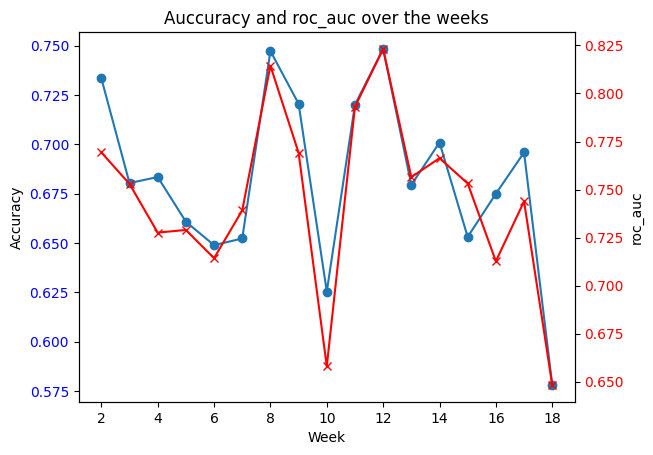

In [23]:
def plot_week(m, features, df, target):
    x = sorted(df["week"].unique())
    y = []

    for week in x:
        y_proba = m.predict_proba(df[df['week'] == week][features])[:,1]
        y_pred = (y_proba > 0.51).astype(int) 
        y_test = df[df['week'] == week][target]
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        
        y.append({
            'week': week,
            'accuracy': acc,
            'roc_auc': auc
        })
    y = pd.DataFrame(y)

    fig, ax1 = plt.subplots()
    ax1.plot(x,y['accuracy'], marker="o", label = "Accuracy")
    ax1.set_xlabel("Week")
    ax1.set_ylabel('Accuracy')
    ax1.tick_params(axis="y", labelcolor="blue")

    ax2 = ax1.twinx()
    ax2.plot(x, y['roc_auc'], color="red", marker="x", label="ROC AUC")
    ax2.set_ylabel('roc_auc')
    ax2.tick_params(axis="y", labelcolor="red")
    plt.title("Auccuracy and roc_auc over the weeks")
    plt.show()
    


plot_week(best_model, currCols,X2, 'home_win')

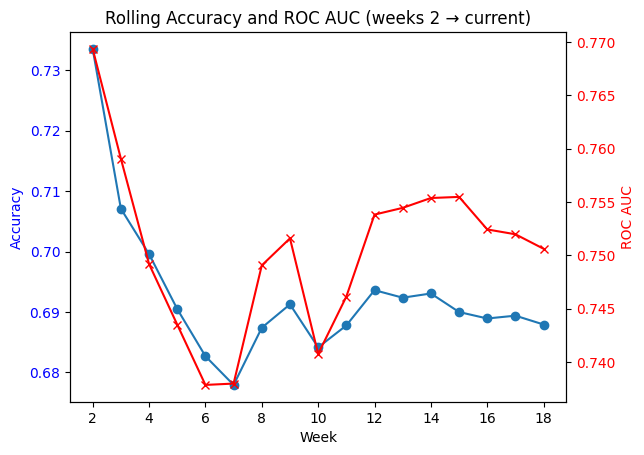

In [24]:
def plot_week_rolling(m, features, df, target):
    x = sorted(df["week"].unique())
    y = []

    for week in x:
        # include all games from week 2 up to current week
        df_window = df[(df["week"] >= 2) & (df["week"] <= week)]

        y_proba = m.predict_proba(df_window[features])[:, 1]
        y_pred = (y_proba > 0.51).astype(int)
        y_test = df_window[target]

        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)

        y.append({
            "week": week,
            "accuracy": acc,
            "roc_auc": auc
        })

    y = pd.DataFrame(y)

    fig, ax1 = plt.subplots()
    ax1.plot(x, y["accuracy"], marker="o", label="Accuracy")
    ax1.set_xlabel("Week")
    ax1.set_ylabel("Accuracy", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")

    ax2 = ax1.twinx()
    ax2.plot(x, y["roc_auc"], color="red", marker="x", label="ROC AUC")
    ax2.set_ylabel("ROC AUC", color="red")
    ax2.tick_params(axis="y", labelcolor="red")

    plt.title("Rolling Accuracy and ROC AUC (weeks 2 → current)")
    plt.show()


plot_week_rolling(best_model, currCols,X2, 'home_win')

In [27]:
y_proba = best_model.predict_proba(X2[currCols])[:,1]
y_pred = (y_proba > 0.51).astype(int) 
y_test = X2['home_win']
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"Accuracy on all years with best model: {acc:.3f}")
print(f"ROC AUC on all years with best model: {auc:.3f}")

y_pred_proba = best_model.predict_proba(X_test_Week_Lim[currCols])[:,1]
#print(y_pred_proba)
y_pred = (y_pred_proba > 0.51).astype(int)


print("Accuracy for testing on unseen seasons in training:", accuracy_score(y_test_Week_Lim, y_pred))
print("ROC AUC for testing on unseen seasons in training:", roc_auc_score(y_test_Week_Lim, y_pred))

Accuracy on all years with best model: 0.688
ROC AUC on all years with best model: 0.751
Accuracy for testing on unseen seasons in training: 0.6484375
ROC AUC for testing on unseen seasons in training: 0.6458282358698312


This project was a lot of fun, and I really enjoyed learning a lot about feature engineering, hyperparameter tuning, and evaluating models in a sports prediction setting. With the tuned XGBoost model, I reached about 68.8% accuracy (ROC AUC 0.75) across all years and 64.8% accuracy (ROC AUC 0.65) when testing on unseen seasons. Its still slightly off the benchmark of Vegas predictions (around 67% accuracy).
There’s still plenty of room for improvement, both in refining the features and experimenting more with parameter tuning but I had a lot of fun. The obvious application here is to try and use my model to sports bet and make money but I doubt that I will be doing that. That being said I would love to start tracking the models predictions for the upcoming 2025 NFL season. Maybe I will come back and see how it fared at the end of the year and keep track of my own predictions of who will win and see who can predict the outcome of football games better.